In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import os

# Wczytaj dane
BASE_DIR = os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
CSV_PATH = os.path.join(BASE_DIR, "data", "posture_data.csv")

df = pd.read_csv(CSV_PATH)

print(f"Kształt danych: {df.shape}")
print(f"\nRozkład klas:")
print(df["label"].value_counts())
print(f"\nCzy są NULLe: {df.isnull().sum().sum()}")
df.head()

Kształt danych: (3058, 22)

Rozkład klas:
label
0    1553
1    1505
Name: count, dtype: int64

Czy są NULLe: 0


,nose_x,nose_y,nose_z,left_eye_x,left_eye_y,left_eye_z,right_eye_x,right_eye_y,right_eye_z,left_ear_x,...,right_ear_x,right_ear_y,right_ear_z,left_shoulder_x,left_shoulder_y,left_shoulder_z,right_shoulder_x,right_shoulder_y,right_shoulder_z,label
0,0.004617,-0.004165,0.035822,0.002985,-0.003470,0.039920,0.005504,-0.001299,0.032122,0.003696,...,0.004766,0.004140,0.006444,0.010337,0.002304,0.053873,0.002556,0.001893,-0.031396,0
1,0.006152,-0.003685,0.048712,0.003081,-0.003278,0.051428,0.006291,-0.001028,0.044485,0.003344,...,0.004867,0.004108,0.017845,0.009486,0.001453,0.067418,0.002722,0.000955,-0.028873,0
2,0.006046,-0.003854,0.057475,0.003031,-0.003469,0.059123,0.006012,-0.001414,0.052117,0.003249,...,0.004474,0.003475,0.025139,0.008888,0.000002,0.075690,0.002846,-0.002020,-0.022002,0
3,0.006033,-0.004469,0.036418,0.003079,-0.003686,0.037849,0.005990,-0.001930,0.034861,0.003392,...,0.004439,0.002344,0.020679,0.008947,-0.000062,0.040626,0.002855,-0.002019,-0.016008,0
4,0.005773,-0.004597,0.028124,0.003046,-0.003769,0.030982,0.005908,-0.002105,0.027057,0.003347,...,0.004422,0.001918,0.015121,0.008528,-0.000539,0.037374,0.002884,-0.002472,-0.013745,0


In [8]:
# Oddziel cechy od etykiet
X = df.drop("label", axis=1)
y = df["label"]

# === NOWY KOD: NORMALIZACJA DANYCH TRENINGOWYCH ===
# 1. Wyliczamy "idealną pozycję" (bazę) dla nagrania, uśredniając wiersze, gdzie postawa była "Dobra" (label 0)
good_posture_rows = df[df["label"] == 0].drop("label", axis=1)
calibration_base = good_posture_rows.mean().to_dict()

# 2. Odejmujemy tę idealną bazę od KAŻDEGO wiersza w zbiorze danych
# Dzięki temu w tabeli X znajdą się tylko RÓŻNICE (czyli to samo, co daje normalizer.py)
for col in X.columns:
    X[col] = X[col] - calibration_base[col]

print("✅ Znormalizowano dane treningowe!")
# ==================================================

print(f"Liczba cech: {X.shape[1]}")
print(f"Nazwy cech: {list(X.columns)}")

# Podział na zbiór treningowy i testowy (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Skalowanie (ważne dla SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\nTreningowe: {X_train.shape}")
print(f"Testowe:    {X_test.shape}")

✅ Znormalizowano dane treningowe!
Liczba cech: 21
Nazwy cech: ['nose_x', 'nose_y', 'nose_z', 'left_eye_x', 'left_eye_y', 'left_eye_z', 'right_eye_x', 'right_eye_y', 'right_eye_z', 'left_ear_x', 'left_ear_y', 'left_ear_z', 'right_ear_x', 'right_ear_y', 'right_ear_z', 'left_shoulder_x', 'left_shoulder_y', 'left_shoulder_z', 'right_shoulder_x', 'right_shoulder_y', 'right_shoulder_z']

Treningowe: (2446, 21)
Testowe:    (612, 21)


In [9]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
# === ZMIANA: używamy przeskalowanych danych (X_train_scaled zamiast X_train) ===
rf_model.fit(X_train_scaled, y_train)  

# === ZMIANA: testujemy na przeskalowanych danych ===
y_pred_rf = rf_model.predict(X_test_scaled)

print("=== RANDOM FOREST ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["Dobra", "Zla"]))

=== RANDOM FOREST ===
Accuracy: 0.9788

Classification Report:
              precision    recall  f1-score   support

       Dobra       0.97      0.99      0.98       311
         Zla       0.99      0.97      0.98       301

    accuracy                           0.98       612
   macro avg       0.98      0.98      0.98       612
weighted avg       0.98      0.98      0.98       612



In [10]:
svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=True,
    random_state=42
)
svm_model.fit(X_train_scaled, y_train)  # SVM wymaga skalowania

y_pred_svm = svm_model.predict(X_test_scaled)

print("=== SVM ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=["Dobra", "Zla"]))

=== SVM ===
Accuracy: 0.9739

Classification Report:
              precision    recall  f1-score   support

       Dobra       0.96      0.99      0.97       311
         Zla       0.99      0.95      0.97       301

    accuracy                           0.97       612
   macro avg       0.97      0.97      0.97       612
weighted avg       0.97      0.97      0.97       612



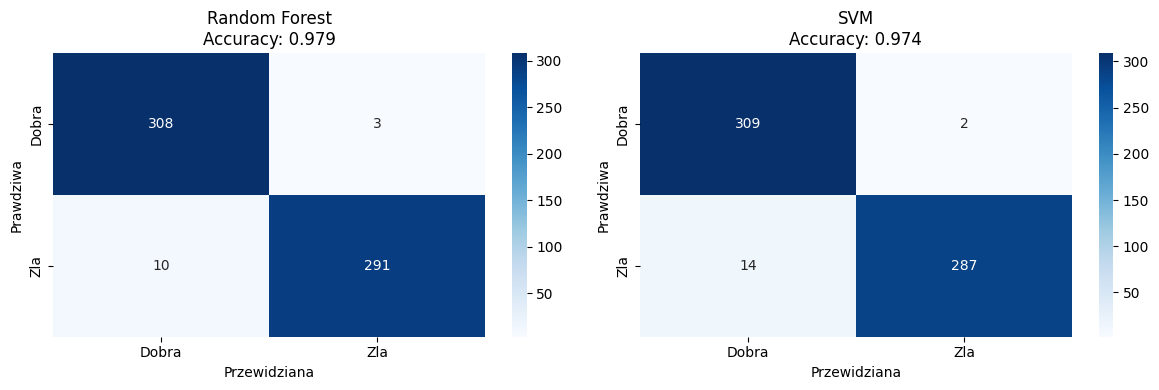

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, y_pred) in zip(axes, [
    ("Random Forest", y_pred_rf),
    ("SVM",           y_pred_svm)
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Dobra", "Zla"],
                yticklabels=["Dobra", "Zla"])
    ax.set_title(f"{name}\nAccuracy: {accuracy_score(y_test, y_pred):.3f}")
    ax.set_ylabel("Prawdziwa")
    ax.set_xlabel("Przewidziana")

plt.tight_layout()
plt.show()

In [12]:
# Porównaj i zapisz lepszy model
rf_acc  = accuracy_score(y_test, y_pred_rf)
svm_acc = accuracy_score(y_test, y_pred_svm)

MODELS_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

if rf_acc >= svm_acc:
    best_name  = "Random Forest"
    joblib.dump(rf_model, os.path.join(MODELS_DIR, "posture_model.pkl"))
    joblib.dump(scaler,   os.path.join(MODELS_DIR, "scaler.pkl"))  # na wszelki wypadek
    print(f"✅ Zapisano Random Forest (accuracy: {rf_acc:.4f})")
else:
    best_name  = "SVM"
    joblib.dump(svm_model, os.path.join(MODELS_DIR, "posture_model.pkl"))
    joblib.dump(scaler,    os.path.join(MODELS_DIR, "scaler.pkl"))
    print(f"✅ Zapisano SVM (accuracy: {svm_acc:.4f})")

print(f"\nNajlepszy model: {best_name}")
print(f"Pliki zapisane w: {MODELS_DIR}")

✅ Zapisano Random Forest (accuracy: 0.9788)

Najlepszy model: Random Forest
Pliki zapisane w: C:\Users\emilk\PycharmProjects\posture_analysis\models
